# More Detailed Studies on GENIE Uncertainties

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import pandas as pd
import numpy as np
import sys
from os import path, makedirs
from datetime import datetime

# local imports
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from makedf.geniesyst import *
from analysis_village.numucc_1p0pi.utils import *
# from analysis_village.numucc_1p0pi.files_config import *
# from analysis_village.numucc_1p0pi.makedf.selections import *
# from pyanalib.split_df_helpers import *
# from pyanalib.pandas_helpers import *
# from pyanalib.covariance import *

import matplotlib.pyplot as plt 
from matplotlib.patches import Patch

plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

mc_n_split: 1
mc_tot_pot: 1.521e+19
Integrated flux: 2.456e+11
# of targets:  1.3251484770937053e+30
XSEC_UNIT is 0, setting to 1e-38
xsec unit:  1e-38


/exp/sbnd/app/users/munjung/xsec/cafpyana_2026Jan17/cafpyana/analysis_village/numucc_1p0pi/constants.py:56: RuntimeWarning: overflow encountered in scalar multiply
  xsec_unit = 1 / (integrated_flux * NTARGETS)


In [4]:
def get_univ_rates(cov_type="rate", 
                    syst_type="GENIE",
                    evtdf=None, 
                    nudf=None, 
                    var_config=None, 
                    syst_name="", 
                    n_univ=100, 
                    bkgd_subtract=True,
                    plot=False):
    """
    for the GENIE uncertainty on the xsec measurement
    """

    if cov_type == "xsec":
        print("getting {} universes for {} uncertainty on the xsec".format(n_univ, syst_name))
        scale_factor = XSEC_UNIT

    elif cov_type == "rate":
        print("getting {} universes for {} uncertainty on the event rate".format(n_univ, syst_name))
        scale_factor = 1.0

    else:
        raise ValueError("Invalid covariance type: {}, choose in [xsec, rate]".format(cov_type))

    bins = var_config.bins

    evtdf_signal = evtdf[evtdf.topo_categ == 1]
    # reco variable histogram, topology breakdown
    evtdf_div_topo = [evtdf[evtdf.topo_categ == mode]for mode in topology_list]

    if nudf is not None:
        nudf_signal = nudf[nudf.topo_categ == 1]

    ret = signal_hists(evtdf, nudf, var_config, return_data=True, plot=plot)

    univ_events = []
    univ_effs   = []
    univ_smears = []

    for uidx in tqdm(range(n_univ), desc="Getting universes"):
        univ_col = f"univ_{uidx}"

        # ---- uncertainty on the signal rate ----
        # only consider effect on the response matrix for the signal channel
        if cov_type == "xsec" and syst_type == "GENIE":
            # smearing matrix
            # handle case where there's a single bin, in which case there's no smearing
            if len(bins) == 2:
                reco_vs_true = np.array([[1.0]])
            else:
                reco_vs_true, _, _ = np.histogram2d(ret["var_sel_truth"], 
                                                    ret["var_sel_reco"], 
                                                    weights=ret["wgt_sel_truth"]*evtdf_signal[syst_name][univ_col],
                                                    bins=bins)
            univ_smears.append(reco_vs_true)

            # efficiency
            signal_allmc_univ, _ = np.histogram(ret["var_allmc"],
                                               weights=ret["wgt_allmc"]*nudf_signal[syst_name][univ_col],
                                               bins=bins)
            signal_sel_univ, _ = np.histogram(ret["var_sel_truth"],
                                               weights=ret["wgt_sel_truth"]*evtdf_signal[syst_name][univ_col],
                                               bins=bins)
            eff = signal_sel_univ / signal_allmc_univ
            univ_effs.append(eff)

            response_univ = get_response_matrix(reco_vs_true, eff)
            signal_univ = response_univ @ ret["nevts_allmc"] # note that we multiply the CV signal rate!
            # signal_univ = signal_cv

        elif cov_type == "rate":
            signal_univ, _ = np.histogram(ret["var_sel_reco"], 
                                          weights=ret["wgt_sel_reco"]*evtdf_signal[syst_name][univ_col],
                                          bins=bins)

        else:
            raise ValueError("Invalid covariance type: {}, choose xsec or rate".format(cov_type))

        # TODO: this isn't computationally efficient, but it's useful for debugging
        # ---- uncertainty on the background rate ----
        # loop over background categories
        # + univ background - cv background
        # note: cv background subtraction cancels out with the cv background subtraction for the cv event rate. 
        #       doing it anyways for the plot of universes on background subtracted event rate.
        for this_evtdf in evtdf_div_topo[1:]:
            var, wgt = get_clipped_evts(this_evtdf, var_config.var_evt_reco_col, bins)
            univ_wgt = this_evtdf[syst_name][univ_col].copy()
            univ_wgt[np.isnan(univ_wgt)] = 1 ## IMPORTANT: make nan univ_wgt to 1. to ignore them
            background_cv, _   = np.histogram(var, bins=bins, weights=wgt)
            background_univ, _ = np.histogram(var, bins=bins, weights=wgt*univ_wgt)

            if bkgd_subtract:
                signal_univ += (background_univ - background_cv)
            else:
                signal_univ += background_univ

        signal_univ *= scale_factor
        univ_events.append(signal_univ)

    univ_events = np.array(univ_events)

    cv_effs = np.zeros(len(bins)-1)
    cv_smears = np.zeros((len(bins)-1, len(bins)-1))
    if bkgd_subtract:
        cv_events = ret["nevts_sel_reco"]
        cv_events *= scale_factor

        if len(bins) == 2:
            reco_vs_true = np.array([[1.0]])
        else:
            reco_vs_true, _, _ = np.histogram2d(ret["var_sel_truth"], 
                                                ret["var_sel_reco"], 
                                                weights=ret["wgt_sel_truth"],
                                                bins=bins)
        cv_smears = reco_vs_true

        # efficiency
        signal_allmc_univ, _ = np.histogram(ret["var_allmc"],
                                            weights=ret["wgt_allmc"],
                                            bins=bins)
        signal_sel_univ, _ = np.histogram(ret["var_sel_truth"],
                                            weights=ret["wgt_sel_truth"],
                                            bins=bins)
        cv_effs = signal_sel_univ / signal_allmc_univ

    else:
        cv_events = ret["nevts_allsel_reco"]
        cv_events *= scale_factor 

    return {"univ_events": univ_events, 
            "cv_events": cv_events,
            "univ_effs": univ_effs,
            "cv_effs": cv_effs,
            "univ_smears": univ_smears,
            "cv_smears": cv_smears}

In [5]:
save_fig = True
show_plot = True

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, "systematics_studies_genie-{}".format(today_str))

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

saving plots in  /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics_studies_genie-20260318


In [9]:
# load dfs

# syst_list = qe_genie_systematics
# genie_tag = "CCQE"

# syst_list = mec_genie_systematics
# genie_tag = "MEC"

# syst_list = res_genie_systematics
# genie_tag = "RES"

# syst_list = other_genie_systematics
# genie_tag = "Other"

syst_list = ar23p_genie_systematics
genie_tag = "Ar23p"


syst_type = f"genie-{genie_tag}"
df_tag = ""
subdir = f"genie_wgts-{genie_tag}"

if genie_tag == "CCQE":
    df_tag="_geniewgts_CCQE"
    subdir = "genie_wgts-CCQE"

# ===== files to process =====
file_dir = "/exp/sbnd/data/users/munjung/xsec/2025Spring_v10_06_00_09"
n_max_concat = 3
mc_keys2load = ['hdr', 'mcnu', 'evt'] 

concat_dfs = load_and_concat_mc_dfs(
    file_dir=file_dir,
    # chunk_tags=generate_tags("bl")[1:],
    chunk_tags=["ad"],
    df_tag=df_tag,
    keys2load=mc_keys2load,
    n_max_concat=n_max_concat,
    sub_dir="MC",
    sample_dir="BNB_cosmics/"+subdir
)

mc_hdr_df = concat_dfs['hdr']
mc_nu_df  = concat_dfs['mcnu']
mc_evt_df = concat_dfs['evt']

# ===== total pot =====
mc_tot_pot = mc_hdr_df['pot'].sum()
print("mc_tot_pot: %.3e" %(mc_tot_pot))
mc_pot_scale = 1.0
mc_evt_df["pot_weight"] = mc_pot_scale * np.ones(len(mc_evt_df))
mc_nu_df["pot_weight"]  = mc_pot_scale * np.ones(len(mc_nu_df))

Keys: ['/evt_0', '/evt_1', '/evt_2', '/evt_3', '/hdr_0', '/hdr_1', '/hdr_2', '/hdr_3', '/histgenevtdf_0', '/histgenevtdf_1', '/histgenevtdf_2', '/histgenevtdf_3', '/histpotdf_0', '/histpotdf_1', '/histpotdf_2', '/histpotdf_3', '/mcnu_0', '/mcnu_1', '/mcnu_2', '/mcnu_3', '/split']
Reading file with tag ad, mc_n_split: 4


mc_tot_pot: 5.364e+19


In [10]:
# mc_evt_df.loc[:,'topo_categ'] = get_topo_category(mc_evt_df)
# mc_evt_df.loc[:,'genie_categ'] = get_genie_category(mc_evt_df)

# mc_nu_df.columns = pd.MultiIndex.from_tuples([tuple(["mc"] + list(c)) for c in mc_nu_df.columns])     # match # of column levels
# mc_nu_df.loc[:,'topo_categ'] = get_topo_category(mc_nu_df)
# mc_nu_df.loc[:,'genie_categ'] = get_genie_category(mc_nu_df)

In [11]:
mc_nu_df

mc                                  \
                                        E    baseline      time  bjorkenX   
                                                                            
                                                                            
__ntuple entry rec.mc.nu..index                                             
5        0     0                 1.014534  100.694153  0.988592  0.266965   
         1     0                 0.765239  119.734200  1.468555  0.945066   
               1                 2.764126  113.340958  0.888086  0.772730   
         2     0                 1.039721  122.213783  1.036805  0.363425   
               1                 4.078794  132.331711  1.538885  0.523145   
...                                   ...         ...       ...       ...   
3566     159   2                 0.310893  114.388138  1.807585  0.519408   
         160   0                 1.796543  118.776314  0.472059  0.957194   
         161   0                 1.024689  123.266449  0.452764  1.011711   
         162   0                 0.900878   88.244774  1.571775  0.120207   
               1                 0.366700   84.939018  0.395204  0.899084   

                                                                             \
                                inelasticityY        Q2         w  momentum   
                                                                          x   
                                                                              
__ntuple entry rec.mc.nu..index                                               
5        0     0                     0.888828  0.452061  1.456997  0.006006   
         1     0                     0.116017  0.157558  0.943783  0.000478   
               1                     0.023711  0.095103  0.953698 -0.055898   
         2     0                     0.739094  0.524432  1.341702 -0.007200   
               1                     0.427072  1.711248  1.562497 -0.123032   
...                                       ...       ...       ...       ...   
3566     159   2                     0.239758  0.072703  0.974083  0.015107   
         160   0                     0.189065  0.610529  0.953347  0.020273   
         161   0                     0.409755  0.797685  0.933988  0.002593   
         162   0                     0.407331  0.082832  1.219762 -0.000112   
               1                     0.279655  0.173138  0.949211  0.014902   

                                                     ...  \
                                                     ...   
                                        y         z  ...   
                                                     ...   
__ntuple entry rec.mc.nu..index                      ...   
5        0     0                -0.012736  1.014436  ...   
         1     0                -0.014006  0.765111  ...   
               1                -0.029806  2.763400  ...   
         2     0                -0.015128  1.039585  ...   
               1                -0.156322  4.073941  ...   
...                                   ...       ...  ...   
3566     159   2                 0.012696  0.310267  ...   
         160   0                -0.011910  1.796389  ...   
         161   0                -0.018173  1.024525  ...   
         162   0                -0.005160  0.900864  ...   
               1                -0.016049  0.366045  ...   

                                                                                        \
                                GENIEReWeight_SBNNuSyst_multisigma_EDepFSI_FrPiProd_pi   
                                                                                univ_0   
                                                                                         
__ntuple entry rec.mc.nu..index                                                          
5        0     0                                                               1.0       
         1     0                        

In [12]:
mc_nu_df.mc["ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1"]

ps1       ms1       ps2       ms2  \
                                                                          
__ntuple entry rec.mc.nu..index                                           
5        0     0                 1.000000  1.000000  1.000000  1.000000   
         1     0                 0.996019  1.055192  0.967299  1.085645   
               1                 0.980887  1.030554  0.956824  1.056158   
         2     0                 1.000000  1.000000  1.000000  1.000000   
               1                 1.000000  1.000000  1.000000  1.000000   
...                                   ...       ...       ...       ...   
3566     159   2                 1.000000  1.000000  1.000000  1.000000   
         160   0                 1.194749  1.262863  1.161658  1.297887   
         161   0                 1.299721  1.367989  1.266288  1.402823   
         162   0                 1.000000  1.000000  1.000000  1.000000   
               1                 1.002854  1.066273  0.971933  1.098771   

                                      ps3       ms3        cv    univ_0  
                                                                         
__ntuple entry rec.mc.nu..index                                          
5        0     0                 1.000000  1.000000  1.000000  1.000000  
         1     0                 0.939157  1.116676  1.025317  0.996019  
               1                 0.933274  1.082276  1.005464  0.980887  
         2     0                 1.000000  1.000000  1.000000  1.000000  
               1                 1.000000  1.000000  1.000000  1.000000  
...                                   ...       ...       ...       ...  
3566     159   2                 1.000000  1.000000  1.000000  1.000000  
         160   0                 1.129211  1.333556  1.228484  1.194749  
         161   0                 1.233321  1.438125  1.333622  1.299721  
         162   0                 1.000000  1.000000  1.000000  1.000000  
               1                 0.941538  1.131796  1.034300  1.002854  

[1096078 rows x 8 columns]

In [13]:
mc_nu_df.mc["ZExpPCAWeighter_SBNNuSyst_multisigma_D_ZExp_b1"]

ps1       ms1       ps2       ms2  \
                                                                          
__ntuple entry rec.mc.nu..index                                           
5        0     0                 1.000000  1.000000  1.000000  1.000000   
         1     0                 1.002026  0.997977  1.004054  0.995957   
               1                 1.000827  0.999174  1.001654  0.998348   
         2     0                 1.000000  1.000000  1.000000  1.000000   
               1                 1.000000  1.000000  1.000000  1.000000   
...                                   ...       ...       ...       ...   
3566     159   2                 1.000000  1.000000  1.000000  1.000000   
         160   0                 1.012003  0.988103  1.024113  0.976312   
         161   0                 1.018222  0.981958  1.036624  0.964095   
         162   0                 1.000000  1.000000  1.000000  1.000000   
               1                 1.002533  0.997471  1.005069  0.994945   

                                      ps3       ms3   cv    univ_0  
                                                                    
__ntuple entry rec.mc.nu..index                                     
5        0     0                 1.000000  1.000000  1.0  1.000000  
         1     0                 1.006085  0.993940  1.0  1.002026  
               1                 1.002482  0.997523  1.0  1.000827  
         2     0                 1.000000  1.000000  1.0  1.000000  
               1                 1.000000  1.000000  1.0  1.000000  
...                                   ...       ...  ...       ...  
3566     159   2                 1.000000  1.000000  1.0  1.000000  
         160   0                 1.036329  0.964628  1.0  1.012003  
         161   0                 1.055206  0.946413  1.0  1.018222  
         162   0                 1.000000  1.000000  1.0  1.000000  
               1                 1.007609  0.992423  1.0  1.002533  

[1096078 rows x 8 columns]

In [16]:
for syst_name in ar23p_genie_systematics:
    type_name = mc_nu_df[("mc", syst_name)].columns[0][0]
    if "univ" in type_name:
        print("skipping multisim")
        continue
    print(type_name)
    mc_nu_df[("mc", syst_name, "univ_0", "")] = mc_nu_df[("mc", syst_name, type_name)].copy()
    mc_evt_df[("mc", syst_name, "univ_0", "", "", "", "")] = mc_evt_df[("mc", syst_name, type_name, "", "", "", "")].copy()

ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1
ps1


In [14]:
var_config = VariableConfig.muon_momentum()

In [19]:
ar23p_genie_systematics

['ZExpPCAWeighter_SBNNuSyst_multisigma_D_ZExp_b1',
 'ZExpPCAWeighter_SBNNuSyst_multisigma_D_ZExp_b2',
 'ZExpPCAWeighter_SBNNuSyst_multisigma_D_ZExp_b3',
 'ZExpPCAWeighter_SBNNuSyst_multisigma_D_ZExp_b4',
 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b1',
 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b2',
 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b3',
 'ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b4',
 'CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin1',
 'CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin2',
 'CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin3',
 'CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin4',
 'CCQETemplateReweight_SBNNuSyst_multisigma_SF_q0bin5',
 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin1',
 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin2',
 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin3',
 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin4',
 'CCQETemplateReweight_SBNNuSyst_multisigma_CRPA_q0bin5',
 'QEInterferen

getting 1 universes for ('mc', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_0') uncertainty on the event rate


Getting universes: 100%|██████████| 1/1 [00:00<00:00, 25.37it/s]


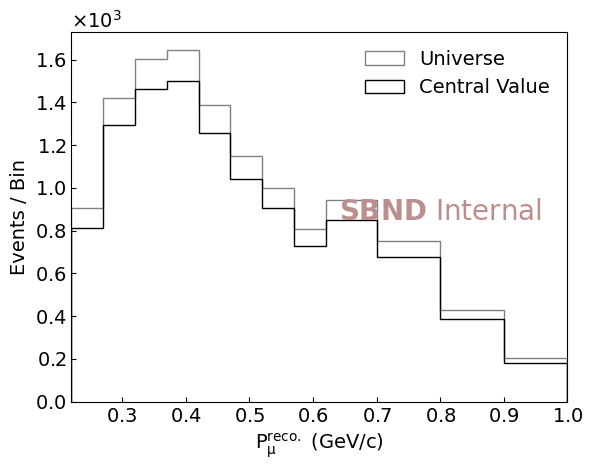

getting 1 universes for ('mc', 'QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_0') uncertainty on the xsec


Getting universes: 100%|██████████| 1/1 [00:00<00:00, 22.55it/s]


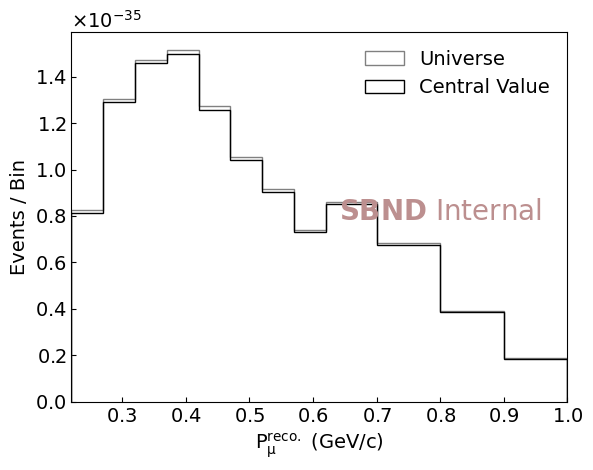

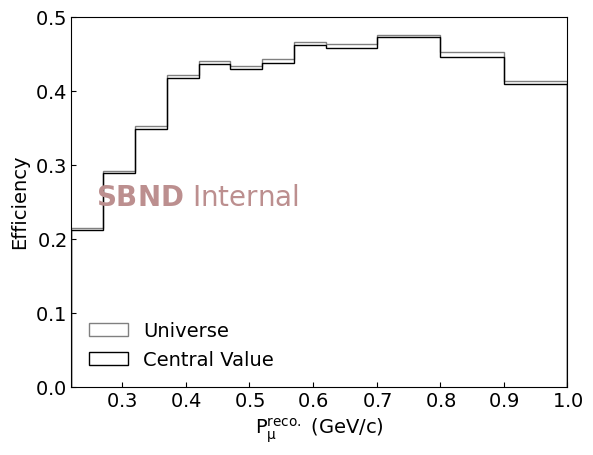

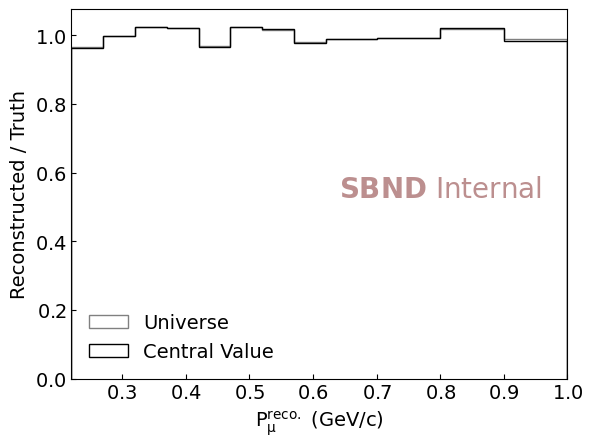

In [26]:
syst_type = "GENIE"
# syst_name = ("mc", "GENIEReWeight_SBN_v1_multisim_RPA_CCQE")
# syst_name = ("mc", "GENIEReWeight_SBN_v1_multisim_NormCCMEC")
# syst_name = ("mc", "GENIEReWeight_SBN_v1_multisigma_MaNCRES")
# syst_name = ("mc", "GENIEReWeight_SBN_v1_multisigma_MFP_N")
# syst_name = ("mc", "ZExpPCAWeighter_SBNNuSyst_multisigma_MvA_ZExp_b2")
syst_name = ("mc", "QEInterference_SBNNuSyst_multisigma_INT_QEIntf_dial_0")
n_univ = 1

# knob_title = "FSI MFP N"
# knob_title = "$M_A$ CCRES"
knob_title = ""
cov_type = "rate"
ret_univs = get_univ_rates(cov_type, syst_type, mc_evt_df, mc_nu_df, var_config, syst_name, n_univ)
univ_events, cv_events = ret_univs["univ_events"], ret_univs["cv_events"]
ret = get_covariance_matrix(univ_events, cv_events)
ax_titles = ["", "Events / Bin", knob_title]
save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-univ_hists"
plot_univ_hists(univ_events, cv_events, syst_name, var_config, ax_titles=ax_titles, plot=show_plot, save_fig=save_fig, save_name=save_name)

cov_type = "xsec"
ret_univs = get_univ_rates(cov_type, syst_type, mc_evt_df, mc_nu_df, var_config, syst_name, n_univ)
univ_events, cv_events = ret_univs["univ_events"], ret_univs["cv_events"]
ret = get_covariance_matrix(univ_events, cv_events)
ax_titles = ["", "Events / Bin", knob_title]
save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-univ_hists"
plot_univ_hists(univ_events, cv_events, syst_name, var_config, ax_titles=ax_titles, plot=show_plot, save_fig=save_fig, save_name=save_name)

# variation of efficiency
univ_events = np.array(ret_univs["univ_effs"])
cv_events = np.array(ret_univs["cv_effs"])
ax_titles = ["", "Efficiency", knob_title]
save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_eff-univ_hists"
plot_univ_hists(univ_events, cv_events, syst_name, var_config, ax_titles=ax_titles, plot=show_plot, save_fig=save_fig, save_name=save_name)

# variation of smearing
ratios = []
for i in range(n_univ):
    var = ret_univs["univ_smears"][i].sum(axis=0) / ret_univs["univ_smears"][i].sum(axis=1)
    ratios.append(var)

univ_events = np.array(ratios)
cv_events = np.array(ret_univs["cv_smears"]).sum(axis=0) / np.array(ret_univs["cv_smears"]).sum(axis=1)
ax_titles = ["", "Reconstructed / Truth", knob_title]
save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_smearing-univ_hists"
plot_univ_hists(univ_events, cv_events, syst_name, var_config, ax_titles=ax_titles, plot=show_plot, save_fig=save_fig, save_name=save_name)

In [ ]:
# ===== plot covariance matrices =====
matrix_type = "cov"
plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Covariance"]
save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-{matrix_type}"
plot_heatmap(ret[matrix_type], 
            var_config.bins, 
            plot_labels=plot_labels,
            plot=plot,
            save_fig=save_fig, save_name=save_name)

matrix_type = "cov_frac"
plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Fractional Covariance"]
save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-{matrix_type}"
plot_heatmap(ret[matrix_type], 
            var_config.bins, 
            plot_labels=plot_labels,
            plot=plot,
            save_fig=save_fig, save_name=save_name)

matrix_type = "corr"
plot_labels = [var_config.var_labels[1], var_config.var_labels[1], "Correlation"]
save_name = f"{save_fig_dir}/{var_config.var_save_name}-{syst_name[1]}_{cov_type}-{matrix_type}"
plot_heatmap(ret[matrix_type], 
            var_config.bins, 
            plot_labels=plot_labels,
            plot=plot,
            save_fig=save_fig, save_name=save_name)